# **ENGG680 - Introduction to Digital Engineering**
## *Lab Assignment 2: Introduction to Non-linear Square and Machine Learning*

## Preliminary: Certificate of Work (5 marks)


*We, the undersigned, certify that this is our own work, which has been done expressly for this course, either without the assistance of any other party or where appropriate we have acknowledged the work of others. Further, we have read and understood the section in the university calendar on plagiarism/cheating/other academic misconduct and we are aware of the implications thereof. We request that the total mark for this assignment be distributed as follows among group members:*

|          | First Name | Last Name | Signature (Full Name, Date) | Hours | Contribution % |
|----------|------------|-----------|-----------------------------|-------|----------------|
| Member 1: | Andrew | Thai | *Andrew Thai*, 11/28/25| 5.5 | 25% |
| Member 2: | Ashley | Whitaker | *Ashley Whitaker*, 11/28/25| 6 | 25% |
| Member 3: | Katie | Lisowski | *Katie Lisowski*, 11/28/25 | 5.5 | 25% |
| Member 4: | Mark Joshua | Ines | *Mark Joshua Ines*, 11/28/25 | 6 | 25% |


# **PART 1: Non-linear Estimation - LSE & Gradiant Decent (35 Marks)**

The following materials will be our states of interest, and we are going to estimate them using **Least Square method** and **Gradient Descent method**

## **SinglePointPositioning Formulas**

### **Observations:** Pseudorange [m]

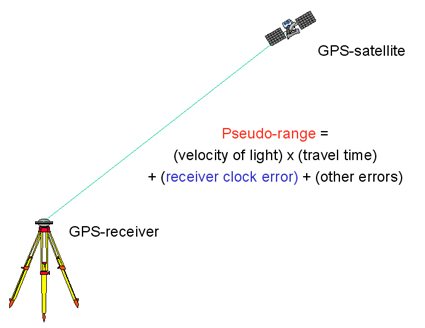

<font size="1.5">Image source: *ICA Course on Toponymy. https://unstats.un.org/unsd/geoinfo/ungegn/docs/_data_icacourses/_HtmlModules/_Selfstudy/S06/S06_05b.html.*</font>

**Pseudorange** is the *pseudo* distance between a satellite and a satellite signal receiver on the ground. In simple words, it contains the geometric range between the satellite and the receiver, with additional associated errors.

The simplified version of the Pseudorange measurement model is:
$$P=\rho-cdT+ϵ_{sum}$$ and
$$\rho=\sqrt{(x_s - x_r)^2 + (y_s - y_r)^2 + (z_s - z_r)^2}$$
where
$$\rho=geometric\ range$$
$${x_s, y_s, z_s, x_r,y_r,z_r} = 3D\ coordinates\ of\ satellite\ and\ receiver$$
$$cdT = receiver\ clock\ offset$$
$$ϵ_{sum}=general\ errors\ term\ (ϵ_{sum}=\Delta \rho + \Delta_{\text{ion}} + \Delta_{\text{trop}} + \epsilon_P + cdt)$$

\
Note: the 3D **positions of satellites** are given in this assignment.

### **Unknown States:** Position of receiver & receiver clock offset

We use the psuedorange measurements to estimate the receiver's **3-dimensional position** and the **receiver clock offset:** $$X={x_r,y_r,z_r,cdT}$$.


## **Setup & Intialization for LSE and Gradient Decent (5 Marks)**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.linalg import inv
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the psuedorange measurements and satellites' positions files, store them in the format of numpy array
# Add small random perturbations in the range (0, 0.5) to pseudorange measurements to simulate measurement noise
# (hint: use pandas library to parse excel files into dataframe first, then convert them to numpy arrays)
# (1 marks)

# Read pseudorange and satellite position data
pr_df = pd.read_excel(
    '/content/drive/MyDrive/ENGG680_2025_Fall/Lab_Assignment2/pseudoranges.xlsx',
    usecols=["Satellite_ID", "P"]
)

sp_df = pd.read_excel(
    '/content/drive/MyDrive/ENGG680_2025_Fall/Lab_Assignment2/satellite_position.xlsx',
    usecols=["Satellite_ID", "x", "y", "z"]
)

# Align satellites: keep only common IDs and enforce consistent ordering
df = (
    sp_df.merge(pr_df, on="Satellite_ID", how="inner")
         .sort_values("Satellite_ID")
         .reset_index(drop=True)
)

# Convert to NumPy arrays with the intended shapes
sat_pos = df[["x", "y", "z"]].to_numpy(dtype=float)   # (N, 3)
pseudorange = df["P"].to_numpy(dtype=float).reshape(-1)  # (N,)

# Add measurement noise
np.random.seed(42)
pseudorange = pseudorange + np.random.uniform(0.0, 0.5, size=pseudorange.shape)

# Optional: check shapes
print("pseudorange.shape =", pseudorange.shape)
print("sat_pos.shape     =", sat_pos.shape)


pseudorange.shape = (11,)
sat_pos.shape     = (11, 3)


In [ ]:
# define the number of measurements n and the number of unknown states m
# (2 mark)
n = len (pseudorange)
m = 4

In [ ]:
# GroundTruth coordiantes of the receiver
GroundTruth=np.array([-1633489.37967725,	-3651627.18250363,	4952481.61954918])

In [ ]:
# define a function called euclidean_norm, which computes the geometric distances between satellites and receiver
# the input of the function should be two arrays: receiver_pos and satellite_pos
# the function should return an array of distance between satellites and receiver
# you can either use the numpy function or code the math manually
# (2 marks)
def euclidean_norm(receiver_pos, satellite_pos):
    # reshape inputs
    rec = np.asarray(receiver_pos, dtype=float).reshape(1, 3)
    sats = np.asarray(satellite_pos, dtype=float).reshape(-1, 3)

    # compute geometric distances
    dist = np.linalg.norm(sats - rec, axis=1)

    return dist


## **Non-linear LSE (15 Marks)**

### Step 1: Given that the variance of observation is 1.2 (m^2), define the weight matrix P (0.5 marks)

In [ ]:
P = (1 / 1.2) * np.eye(n)

### Step 2: set the initial states as [100.0, -50.0, 25.0, 1000.0] (0.5 mark)

In [ ]:
x_0 = np.array([100.0, -50.0, 25.0, 1000.0],dtype=float)

### Step 3: initialize the corrections array as 10s, iteration loop counter i as zero and related arrays (1 mark)

In [ ]:
# initial correction vector (all 10s)
delta = np.full(m, 10.0, dtype=float)

# iteration counter
i = 0

# arrays to store iteration history
arr_w = []          # misclosure / residuals
arr_delta = []      # correction vectors
arr_err_pos = []    # position error
arr_i = []          # iteration index

# start from the initial guess
x_hat = x_0.copy()


### Step 4: define a function named design_matrix which computes the design matrix A of this LSE problem (3 mark)

the input of this funciton should be: estimated unknown states array, satellites positions array and geometric distance array

the function should return an two-dimensional array which represents the design matrix A

#### Calculation Formula for the Design Matrix \( A \)

Let the position vectors of the satellite and receiver be:

- **r** = (r_x, r_y, r_z) for the receiver
- **s** = (s_x, s_y, s_z) for the satellite

The Euclidean distance between the satellite and receiver is given by:

$$
\rho = \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}
$$

#### Partial Derivatives of the Distance with Respect to \(x\), \(y\), and \(z\):

To construct the design matrix, we compute the partial derivatives of the distance function with respect to the receiver's \(x\), \(y\), and \(z\) coordinates. Here's the detailed process for one of them, and the others follow the same procedure.

##### Partial derivative with respect to \(r_x\):

Taking the derivative with respect to \(r_x\), we use the chain rule:

$$
\frac{\partial \rho}{\partial r_x} = \frac{\partial}{\partial r_x} \left( \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2} \right)
$$

First, apply the derivative of the square root:

$$
\frac{\partial \rho}{\partial r_x} = \frac{1}{2 \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}} \cdot 2 (r_x - s_x)
$$

Simplifying:

$$
\frac{\partial \rho}{\partial r_x} = \frac{r_x - s_x}{\rho}
$$

##### Partial derivatives for \(r_y\) and \(r_z\):

The partial derivatives with respect to \(r_y\) and \(r_z\) follow the same procedure:

$$
\frac{\partial \rho}{\partial r_y} = \frac{r_y - s_y}{\rho}
$$

$$
\frac{\partial \rho}{\partial r_z} = \frac{r_z - s_z}{\rho}
$$

#### The Design Matrix \(A\):

Thus, the design matrix \(A\) can be expressed as:

$$
A = \left[
\begin{array}{ccc|c}
\frac{s_x - r_x}{\text{distance}} & \frac{s_y - r_y}{\text{distance}} & \frac{s_z - r_z}{\text{distance}} & -1
\end{array}
\right]
$$

Where:
- The first three columns represent the partial derivatives of the distance with respect to x, y, and z coordinates
- The last column of -1 corresponds to the constant term in the least squares equation

This matrix is used for least squares estimation in positioning or navigation applications.


In [ ]:
def design_matrix(x_hat, sat_pos, distance):
    # reshape inputs properly
    x_hat = np.asarray(x_hat, dtype=float).reshape(4,)
    sat_pos = np.asarray(sat_pos, dtype=float).reshape(-1, 3)
    distance = np.asarray(distance, dtype=float).reshape(-1,)

    # receiver coordinates
    rx, ry, rz, _ = x_hat

    # line-of-sight vectors (satellite − receiver)
    los = sat_pos - np.array([rx, ry, rz])

    # unit vectors
    u = los / distance[:, None]

    # build design matrix
    n = sat_pos.shape[0]
    A = np.empty((n, 4))
    A[:, :3] = -u
    A[:, 3] = -1.0

    return A


### Step 5: start the iteration for the LSE (4 mark)

define the convergence criteria for the 'while' loop

the convergence criteria is that the corrections delta are less than 0.008 (i.e., <0.1 m), for receiver's position x,y,z part

In [ ]:
# convergence threshold and maximum iterations
corr_delta     = 0.008
max_iterations = 10000
i = 0  # iteration counter

while i < max_iterations:

    # increment iteration counter at the start
    i += 1

    # 1) geometric distance between satellites and receiver
    distance = euclidean_norm(x_hat[:3], sat_pos)      # shape (n,)

    # 2) design matrix
    A = design_matrix(x_hat, sat_pos, distance)        # shape (n, 4)

    # 3) misclosure vector w = observed - computed
    computed = distance - x_hat[3]                     # modeled pseudorange
    w = pseudorange - computed                         # use 'pseudorange' with noise already added

    # 4) normal equations N * delta = u
    N = A.T @ P @ A
    u = A.T @ P @ w
    delta = np.linalg.solve(N, u)                      # correction vector (4,)

    # 5) update state estimate
    x_hat = x_hat + delta

    # 6) position error relative to ground truth (3D vector)
    err_pos = x_hat[:3] - GroundTruth

    # 7) store history for plotting / analysis
    arr_w.append(w.copy())             # full residual vector
    arr_delta.append(delta.copy())     # full correction vector
    arr_err_pos.append(err_pos.copy()) # 3D error vector
    arr_i.append(i)                    # iteration index

    # 8) convergence check on position components
    if np.linalg.norm(delta[0:3]) < corr_delta:
        print("Converged in", i, "iterations.")
        break

# A posteriori variance of unit weight
apv = (w.T @ P @ w) / (n - m)

# covariance matrix of estimated states
C_x_hat = apv * np.linalg.inv(N)

print("\nx_hat [X, Y, Z, cdT] (m):", np.round(x_hat, 6))
print("Final 3D error vector (m):", np.round(err_pos, 6))
print("Final 3D error norm (m):", np.round(np.linalg.norm(err_pos), 6))


Converged in 5 iterations.

x_hat [X, Y, Z, cdT] (m): [-1.63349246e+06 -3.65162953e+06  4.95248542e+06 -6.70248000e+00]
Final 3D error vector (m): [-3.076349 -2.350835  3.801181]
Final 3D error norm (m): 5.425802


### Step 6: Results Printing (1 mark)

Print:

* estimated states,
* corrections array,
* estimated measurements residuals,
* A posteriori Variance of Unit Weight,
* Covariance matrix of estimated states,
* number of iterations,
* 3-D position errors


In [ ]:
print("\n===== Final Results =====\n")

# 1) Estimated states
print("Estimated states (x_hat) [X, Y, Z, cdT] (m):")
print(np.round(x_hat, 6), "\n")

# 2) Final corrections (last delta)
print("Final corrections (delta) (m):")
print(np.round(delta, 6), "\n")

# 3) Measurement residuals
print("Measurement residuals w (m):")
print(np.round(w, 6), "\n")

rms_residual = np.sqrt(np.mean(w**2))
print("RMS residual (m):")
print(np.round(rms_residual, 6), "\n")

# 4) A posteriori variance of unit weight
print("A posteriori variance of unit weight (sigma_0^2):")
print(np.round(apv, 6), "\n")

# 5) Covariance matrix of estimated states
print("Covariance matrix C_x_hat (m^2):")
print(np.round(C_x_hat, 6), "\n")

# 6) Number of iterations
print("Number of iterations:")
print(i, "\n")

# 7) Final 3D position error
pos_error = np.linalg.norm(x_hat[:3] - GroundTruth)
print("Final 3D position error (m):")
print(np.round(pos_error, 6))



===== Final Results =====

Estimated states (x_hat) [X, Y, Z, cdT] (m):
[-1.63349246e+06 -3.65162953e+06  4.95248542e+06 -6.70248000e+00] 

Final corrections (delta) (m):
[ 3.0e-06  6.0e-06 -1.8e-05  2.1e-05] 

Measurement residuals w (m):
[ 0.204832  0.342405 -0.98044   0.065998  0.047086 -1.570802 -0.309209
  1.699577  0.335242  0.74094  -0.57575 ] 

RMS residual (m):
0.829649 

A posteriori variance of unit weight (sigma_0^2):
0.901368 

Covariance matrix C_x_hat (m^2):
[[ 0.345747  0.07535  -0.091477  0.079034]
 [ 0.07535   0.460205 -0.628511  0.398324]
 [-0.091477 -0.628511  2.212607 -1.194154]
 [ 0.079034  0.398324 -1.194154  0.756346]] 

Number of iterations:
5 

Final 3D position error (m):
5.425802


### Step 7: Comment on the computed A Posteriori Variance of Unit Weight value and the Covariance matrix of estimated states (1 mark)

In [ ]:
# The computed APV (σ₀² ≈ 0.901) being close to 1 indicates that the assumed
# measurement variance (1.2 m²) matches well with the actual noise level in the pseudorange data.

# A value slightly under 1 suggests the observations fit the model a bit better
# than expected, but still remain within a realistic and acceptable range.

# This shows that the observation model, the linearization steps, and the weighting
# matrix are all appropriate for the dataset used.

# The covariance matrix represents the estimated uncertainty for the four unknowns:
# the receiver coordinates (X, Y, Z) and the receiver clock bias (cdT).

# Small diagonal values indicate that the solution for the receiver position
# and clock offset is well constrained by the measurements.

# The off-diagonal elements show correlations between parameters:
# - The X, Y, and Z components are moderately correlated because the satellite
#   geometry links the three spatial dimensions.
# - The clock bias is also correlated with position, which is expected since
#   a timing offset affects all measured ranges in the same direction.


### Step 8: Using the imported matplotlib, plot the following. Make sure to include proper axes information, legend, grid lines and title. (3 marks)

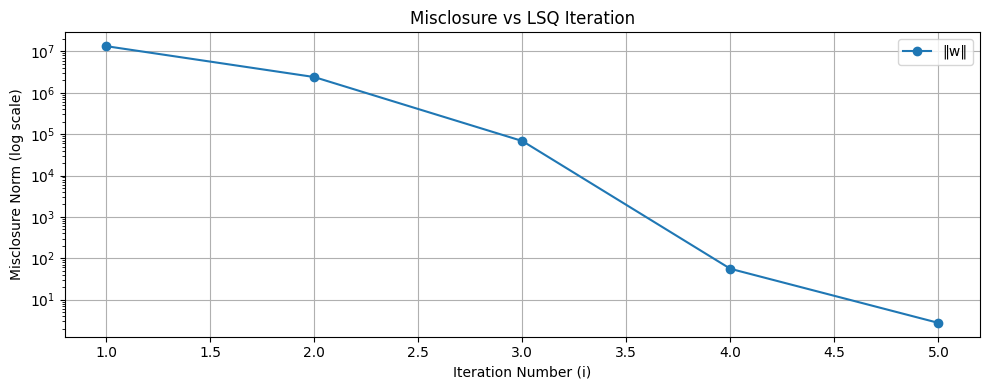

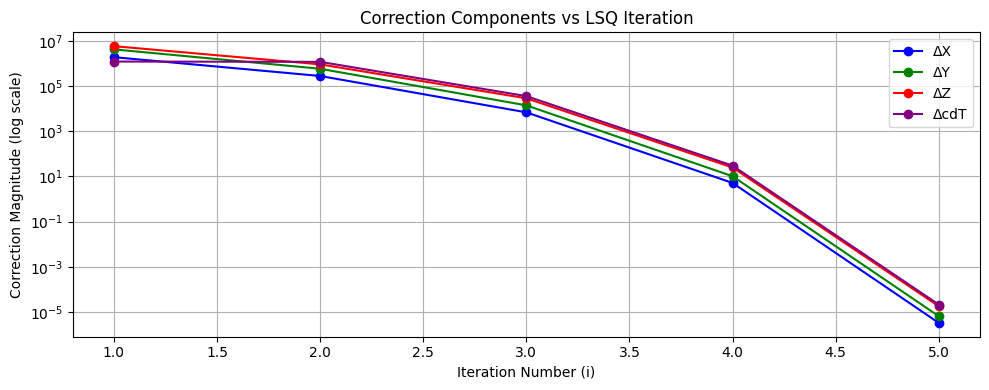

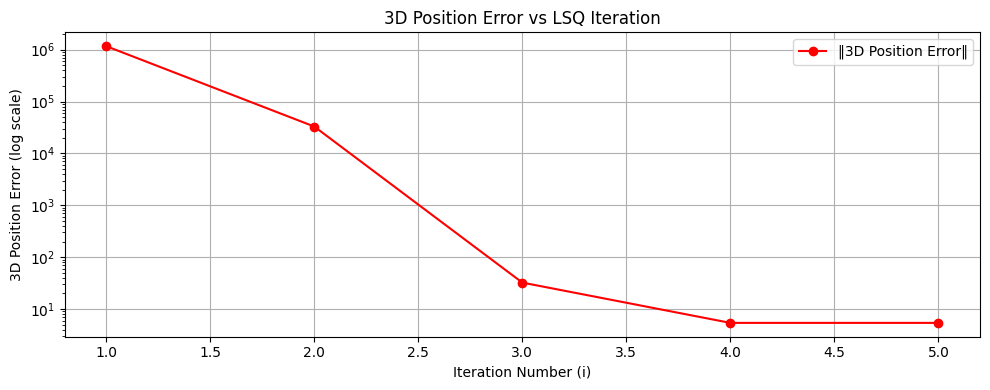

Comment:
All three plots show rapidly decreasing values that level off, indicating that the least squares iterations steadily refine the estimate until convergence.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ensure arrays are NumPy arrays
arr_w       = np.asarray(arr_w)
arr_delta   = np.asarray(arr_delta)
arr_err_pos = np.asarray(arr_err_pos)
arr_i       = np.asarray(arr_i)

# --- 1. Misclosure norm vs iteration (log scale) ---

w_norm = np.linalg.norm(arr_w, axis=1)  # norm per iteration

plt.figure(figsize=(10, 4))
plt.semilogy(arr_i, w_norm + 1e-12, marker='o', linestyle='-', label='‖w‖')
plt.xlabel("Iteration Number (i)")
plt.ylabel("Misclosure Norm (log scale)")
plt.title("Misclosure vs LSQ Iteration")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- 2. Corrections (delta) components vs iteration (log scale) ---

plt.figure(figsize=(10, 4))

delta_labels = ["ΔX", "ΔY", "ΔZ", "ΔcdT"]
delta_colors = ["blue", "green", "red", "purple"]

for k in range(4):
    plt.semilogy(arr_i,
                 np.abs(arr_delta[:, k]) + 1e-12,
                 marker='o',
                 linestyle='-',
                 color=delta_colors[k],
                 label=delta_labels[k])

plt.xlabel("Iteration Number (i)")
plt.ylabel("Correction Magnitude (log scale)")
plt.title("Correction Components vs LSQ Iteration")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- 3. 3D position error norm vs iteration (log scale) ---

pos_err_norm = np.linalg.norm(arr_err_pos, axis=1)

plt.figure(figsize=(10, 4))
plt.semilogy(arr_i,
             pos_err_norm + 1e-12,
             marker='o',
             linestyle='-',
             color='red',
             label='‖3D Position Error‖')
plt.xlabel("Iteration Number (i)")
plt.ylabel("3D Position Error (log scale)")
plt.title("3D Position Error vs LSQ Iteration")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# optional summary comment
print("Comment:")
print("All three plots show rapidly decreasing values that level off, indicating "
      "that the least squares iterations steadily refine the estimate until convergence.")


### Step 9: Describe the phenomena or pattern you recognize for each plot, and explain such phenomena (1 marks)

In [ ]:
# The three plots show values that drop quickly at the start and then level off,
# which indicates that the least squares iterations are steadily reducing the
# residuals and parameter corrections.
# This behavior demonstrates that the algorithm is converging properly and
# gradually refining the receiver position estimate to a stable and reliable solution.


### Bonus: this is just for fun (no marks allocated)

now that you have estimated the receiver's position in Earth-center-earth-fixed (ECEF)

you can use this tool: https://www.oc.nps.edu/oc2902w/coord/llhxyz.htm to convert it to latitude, longitude and height

and find where is it on google earth!

## **Non-linear Gradient Decent (15 Marks)**

### Step 0: Intialize empty arrays (there is no need to fill anything here)

In [ ]:
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

### Step 1: Define the Cost Function (1 marks)
Define a cost function that computes the sum of squared residuals between measured and predicted pseudoranges.

The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.

The function returns a single scalar.

Call euclidean_norm function to calculate geometric distance.

In [ ]:
def cost_function(rec_pos, cdT, sat_pos, pseudorange):

    distance  = euclidean_norm(rec_pos, sat_pos)   # (N,)
    predicted = distance - cdT                     # (N,)
    residuals = pseudorange - predicted            # (N,)
    L = (1/n) * np.sum(residuals ** 2)
    return L

### Step 2: Define the Gradient Computation Function (1 marks)

Define a gradient computation function that calculates the gradient of the cost function with respect to the estimates (x_r, y_r, z_r, cdT).


The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.


The function returns a 1D numpy array that contains 4 elements.


Call euclidean_norm function to calculate geometric distance.


**Recall elements of the design matrix A in the previous LSE function.**

In [ ]:
def gradient(rec_pos, cdT, sat_pos, pseudorange):

    distance = euclidean_norm(rec_pos, sat_pos)    # (N,)
    predicted = distance - cdT                     # (N,)
    residuals = pseudorange - predicted            # (N,)

    grad_x_r = (-2/n) * np.sum(residuals * (rec_pos[0] - sat_pos[:,0]) / distance)
    grad_y_r = (-2/n) * np.sum(residuals * (rec_pos[1] - sat_pos[:,1]) / distance)
    grad_z_r = (-2/n) * np.sum(residuals * (rec_pos[2] - sat_pos[:,2]) / distance)
    grad_cdt = (-2/n) * -np.sum(residuals)
    grad = np.array([grad_x_r, grad_y_r, grad_z_r, grad_cdt])
    return grad

### Step 3: Gradient Descent Implementation (4 marks)
Construct the implementation function of gradient descent

Replace '...' with actual implementation

The function's input are: observed pseudoranges, satellites' positions, learning_rate, maximum loop iterations, tolerance

The function will return a 1D numpy array that contains the optimized estimates (x_r, y_r, z_r, cdT)

The function set learning_rate, max_iters and tolerance as: 0.08, 10000, 8e-7 as default values

These default hyperparameters values can be overridden by passing your own values when calling the function


In [ ]:
# Gradient descent algorithm for non-linear least squares estimation
def gradient_descent(pseudorange, sat_pos, learning_rate=0.08, max_iters=10000, tolerance=8e-7):

    global steps_count
    print("Learning Rate:")
    print(learning_rate)

    #initalize the estimates as zeros
    X = np.array([0,0,0,0])

    for iteration in range(max_iters):
        rec_pos = X[:3]
        cdT = X[3]

        # compute the cost in the current step
        # (1 mark)
        current_cost = cost_function(rec_pos, cdT, sat_pos, pseudorange)


        # compute the gradients in the current step
        # (1 mark)
        grad = gradient(rec_pos, cdT, sat_pos, pseudorange)


        # update estimates
        # (1 mark)
        X_new = X - learning_rate * grad

        # compute the new cost
        # (1 mark)
        new_cost = cost_function(X_new[:3], X_new[3], sat_pos, pseudorange)

        # break the loop if converge
        if np.abs(new_cost - current_cost) < tolerance:
            print(f"Converged after {iteration} iterations.")
            steps_count=iteration
            break

        # update the parameters for the next iteration
        X = X_new

        #collect intermediate results for cost and gradients
        arr_cost.append(current_cost)
        arr_grad.append(grad)
        arr_err.append(X[:3]-GroundTruth)

    return X, arr_cost, arr_grad, arr_err

### Step 4: Parameters Optimization & Results Printing (2 marks)

Call *gradient_descent* function to optimize the estimating parameters using default optimization hyperparameters

Print:

*   optimized parameters
*   final position errors of receiver
*   number of steps taken for convergence
*   final cost value
*   final gradient values








In [ ]:
optimized_params, arr_cost, arr_grad, arr_err = gradient_descent(pseudorange, sat_pos)
final_position_errors = arr_err[-1]
final_cost = arr_cost[-1]
final_gradient = arr_grad[-1]

# print the mentioned metrics
print("Optimized Parameters:", optimized_params)
print("Final Position Errors (Vector):", final_position_errors)
print("Final Position Errors (Norm):", np.round(np.linalg.norm(np.array(final_position_errors)),6))
print("Steps Taken:", steps_count)
print("Final Cost:", arr_cost[-1])
print("Final Gradient:", arr_grad[-1])


Learning Rate:
0.08
Converged after 3707 iterations.
Optimized Parameters: [-1.63349245e+06 -3.65162952e+06  4.95248538e+06 -6.67895963e+00]
Final Position Errors (Vector): [-3.07392655 -2.33733685  3.75969368]
Final Position Errors (Norm): 5.38957
Steps Taken: 3707
Final Cost: 0.6883960844682057
Final Gradient: [ 0.0001545   0.00086087 -0.00264581  0.00149998]


### Step 5: Cost vs Steps Plot & Analysis (1 marks)
Plot cost vs steps

Use 'semilogy' to scale y-axis

Label each axis

Include figure title

Comment on the pattern from the plot

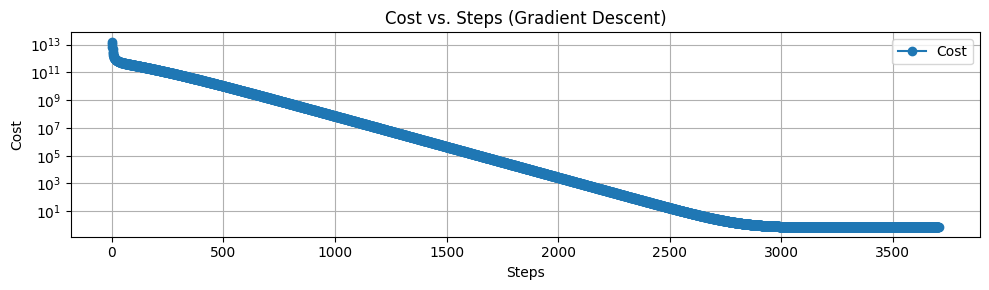

In [ ]:
fig , ax = plt.subplots(nrows=1, ncols=1, figsize=(10,3))

# (0.5 marks)
ax.semilogy(arr_cost, label='Cost', marker='o')
ax.set_xlabel('Steps')
ax.set_ylabel('Cost')
ax.set_title('Cost vs. Steps (Gradient Descent)')
ax.legend()

ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
# The plot shows a sharp drop in cost during the early iterations, followed by a slow
# flattening of the curve. This means gradient descent eliminates most of the large
# errors quickly, and then refines the solution gradually as it gets closer to the
# true receiver position.



### Step 6: Gradients vs Steps & Analysis(1 marks)
Plot gradients vs steps

use 'symlog' to scale y-axis

use 'tick_params' and set y-axis: labelsize=8

include axes' labels, legends and title

Comment on the pattern from the plot

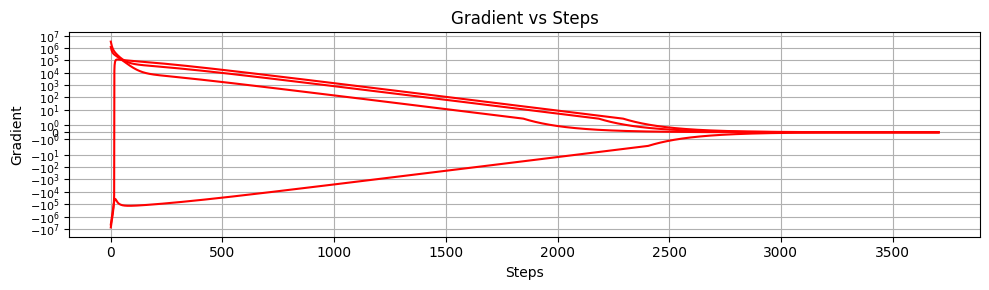

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))
ax.plot(arr_grad, linestyle= '-', color='red')
ax.set_yscale('symlog')
ax.tick_params(axis='y', labelsize=8)
ax.set_xlabel("Steps")
ax.set_ylabel("Gradient")
ax.set_title("Gradient vs Steps")
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
# The gradient values steadily shrink with each iteration, showing that the update
# steps become smaller as the algorithm approaches the optimum and moves closer to
# convergence.


### Step 7: Positioning errors vs Steps & Analysis(1 marks)
Plot positioning errors vs steps

Include axes' labels, legends and title

Comment on the pattern of the plot

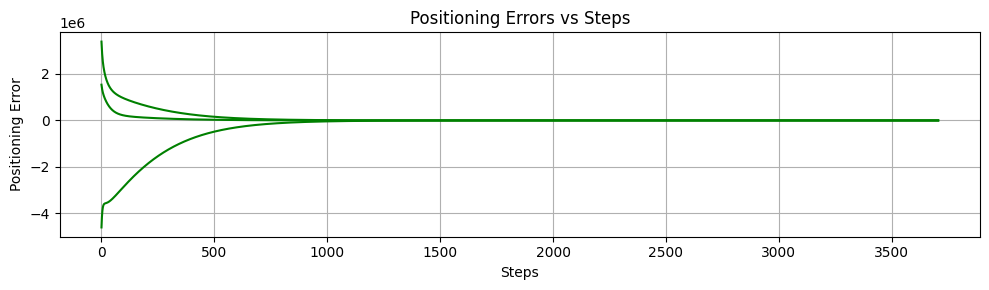

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))
ax.plot(arr_err, linestyle='-', color='green')
ax.set_xlabel("Steps")
ax.set_ylabel("Positioning Error")
ax.set_title("Positioning Errors vs Steps")
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
# The position errors consistently shrink over the iterations, indicating that the
# estimated receiver coordinates are gradually moving closer to the true location as
# the optimization converges.


### **Hyperparameters Tuning**

### Step 8: Tuning Learning rate (2 marks)

Change learning rate to 0.008, 0.0008 and repeat step 4.

(*hint: you may need to adjust the maximum loop iterations in this case*)

In [ ]:
#set learning rate to 0.008
#re-initialize arrays and counters
arr_cost = []
arr_grad = []
arr_err = []
steps_count = 0

optimized_params_2, arr_cost, arr_grad, arr_err = gradient_descent(pseudorange, sat_pos,0.008,100000) #updated max_iters

# print the metrics
print("Optimized Parameters:", optimized_params_2)

Learning Rate:
0.008
Converged after 34876 iterations.
Optimized Parameters: [-1.63349245e+06 -3.65162949e+06  4.95248529e+06 -6.62772566e+00]


In [ ]:
#set learning rate to 0.0008
#re-initialize arrays and counters
arr_cost = []
arr_grad = []
arr_err = []
steps_count = 0

optimized_params_3, arr_cost, arr_grad, arr_err = gradient_descent(pseudorange, sat_pos,0.0008,1000000) #updated max_iters

# print the metrics
print("Optimized Parameters:", optimized_params_3)

Learning Rate:
0.0008
Converged after 326157 iterations.
Optimized Parameters: [-1.63349243e+06 -3.65162940e+06  4.95248500e+06 -6.46607896e+00]


### Step 9: Results Analysis (2 marks)

Q1. Comment on the difference that you notice after changing the learning rate. (1 mark)

Q2. What is the difference between LSE and Gradient Descent? (Comment based on your results and the methodology) (1 mark)


In [ ]:
# Q1 – With a larger learning rate (0.008), the algorithm reaches a solution much more quickly,
# but it can also become unstable or overshoot the minimum. Using a smaller learning rate (0.0008)
# makes the updates safer and more controlled, but the convergence becomes very slow and may require
# increasing the maximum number of iterations to reach a valid solution.

# Q2 – The least squares estimation method converges quickly and gives a precise, statistically
# justified result in just a few iterations. Gradient descent, on the other hand, relies on many
# small updates and needs careful tuning of its parameters, but over time it moves toward the same
# solution through gradual refinement.


# **PART 2: Student Depression Prediction using Logistic Regression (30 Marks)**

The following depression dataset aims at analyzing, understanding, and predicting depression levels among students. It is collected from Shodolamu Opeyemi, and it can be downloaded from https://www.kaggle.com/datasets/hopesb/student-depression-dataset

**Dataset Description:**
- Features include academic pressure, age, CGPA, financial stress, work/study hours, and other psychological factors
- Target variable: Depression status (0 = Not Depressed, 1 = Depressed)

Follow the steps provided to perform binary classification using logistic regression and complete the analysis for each part.



### Step 0: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Step 1: Data Input (2 marks)

Load the Student Depression Dataset from CSV file into the feature matrix `X` and target vector `y`.

Print the size of `X` and `y`

In [ ]:
# Load the Student Depression Dataset
data = pd.read_csv('/content/drive/MyDrive/ENGG680_2025_Fall/Lab_Assignment2/Student Depression Dataset.csv')

# Basic data preprocessing
data = data.drop(columns='id')  # Remove irrelevant ID column
data = data.dropna()  # Remove rows with missing values
data = data.drop_duplicates(   )  # Remove duplicate rows

# Remove 'Other' category entries as they provide no useful information (1 marks)
# your code here
count_others1 = (data=='Others').sum().sum()
print("Total number of 'others' in the dataset before dropping", count_others1)
data = data.drop(data[data.isin(['Others']).any(axis=1)].index)
count_others2 = (data=='Others').sum().sum()
print("Total number of 'others' in the dataset after dropping", count_others2)
# Print the shape of the dataset after preprocessing and display the first 5 rows using head()
# your code here
print("Shape of the dataset after preprocessing:", data.shape)
data.head()

Total number of 'others' in the dataset before dropping 65
Total number of 'others' in the dataset after dropping 0
Shape of the dataset after preprocessing: (27833, 17)


,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Label encode categorical variables
labelencoder = LabelEncoder()
categorical_columns = ['City', 'Gender', 'Sleep Duration', 'Dietary Habits',
                      'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness',
                      'Degree', 'Profession']

for col in categorical_columns:
    if col in data.columns:
        data[col] = labelencoder.fit_transform(data[col])

# Prepare feature matrix X and target vector y (1 marks)
y =  data['Depression'] # Target vector
X = data.drop(columns=['Depression']) # Feature matrix

# Display sizes of X and y
# your code here
print("Size of X:", X.shape)
print("Size of y:", y.shape)


Size of X: (27833, 16)
Size of y: (27833,)


### Step 2.1: Class Label Histogram (1 marks)

Plot the histogram for each class label to visualize class distribution. Display the exact value of the samples for each class above the respective bins.

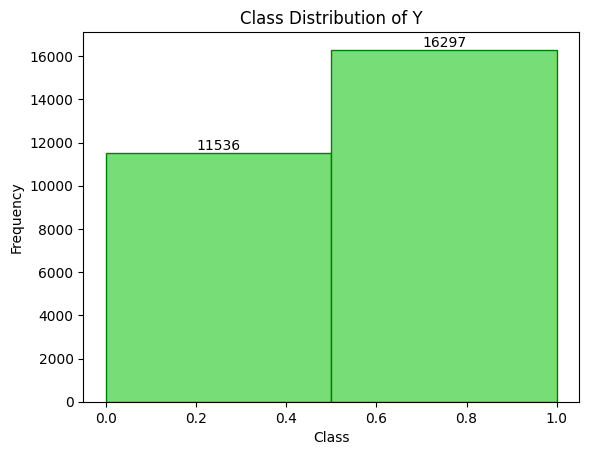

In [ ]:
# Check the class distribution of y
import matplotlib.pyplot as plt
counts, bins, patches = plt.hist(y, bins=len(y.unique()), color='#77dd77', edgecolor = 'green')
plt.title('Class Distribution of Y')
plt.xlabel('Class')
plt.ylabel('Frequency')
# Display exact values for each bin in the histogram
# hint: Use for loop
# your code here
for count, patch in zip(counts, patches):
  x=patch.get_x() + patch.get_width()/2
  y_pos = count
  plt.text(x,y_pos, str(int(count)), ha='center', va='bottom')
plt.show()

### Step 2.2: Smaller Dataset Creation (1 marks)

We also want to test if the model would still work if we used less data. Use the `train_test_split` function from sklearn to create a new feature matrix named `X_small` and a new target vector named `y_small` that contain **3%** of the data.

Use random_state = 42

In [ ]:
from sklearn.model_selection import train_test_split

# Create a smaller dataset with 3% of the data (0.5 marks)
X_test, X_small, y_test, y_small = train_test_split(X, y, test_size=0.03, random_state=42, stratify=y)

# Display sizes of X_small and y_small (0.5 marks)
print("Size of X_small:", X_small.shape)
print("Size of y_small:", y_small.shape)

Size of X_small: (835, 16)
Size of y_small: (835,)


### Step 3: Implement Machine Learning Model (3 marks)

1. Import `LogisticRegression` from sklearn
2. Instantiate model `LogisticRegression(max_iter=2000)`
3. Implement the machine learning model with three different datasets:
    - `X` and `y` (1 mark)
    - Only first two columns of `X` and `y` (1 mark)  
    - `X_small` and `y_small` (1 mark)

### Step 4: Test Model (3 x 3 = 9 marks)

Calculate the following for the **three different tests** implemented in Step 3:
1. data size (0.5 mark)
2. number of training samples (0.5 mark)
3. number of testing samples (0.5 mark)
4. training accuracy (0.5 mark)
5. testing accuracy (0.5 mark)
6. log loss (0.5 mark)

### Step 5.1: Visualize Results (2 marks)

1. Create a pandas DataFrame `results` with columns: Data size, training samples, testing samples, training accuracy, testing accuracy, log loss
2. Add these columns for each dataset to the `results` DataFrame
3. Print `results`

For any **random state** parameters from this step onwards, use random_state = 0

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import train_test_split

# Complete steps 3, 4, and 5.1 in this code block
# Note: 70% training set, 30% testing set
# Create a function that calculates all required information

model = LogisticRegression(max_iter=2000)
results = pd.DataFrame(columns=["Data size", "Training samples", "Testing samples",
                               "Training accuracy", "Testing accuracy", "Log loss"])

# Declare global variables
y_test = None
y_test_pred = None

def evaluate_model(X, y):
    global y_test, y_test_pred # Declare them as global inside the function
    X_train, X_test_local, y_train, y_test_local = train_test_split(X, y, test_size=0.3, random_state=0)
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred_local = model.predict(X_test_local)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test_local, y_test_pred_local)
    logloss = log_loss(y_test_local, model.predict_proba(X_test_local)[:,1])
    return X.shape[0], X_train.shape[0], X_test_local.shape[0], train_accuracy, test_accuracy, logloss, y_test_local, y_test_pred_local

# Test 1: Full dataset (X and y)
data_size, train_samples, test_samples, train_accuracy, test_accuracy, logloss, y_test, y_test_pred = evaluate_model(X, y)
results.loc[0] = [data_size, train_samples, test_samples, train_accuracy, test_accuracy, logloss]
# Test 2: Only first two columns of X and y
data_size, train_samples, test_samples, train_accuracy, test_accuracy, logloss, _, _ = evaluate_model(X.iloc[:, :2], y)
results.loc[1] = [data_size, train_samples, test_samples, train_accuracy, test_accuracy, logloss]
# Test 3: Small dataset (X_small and y_small)
data_size, train_samples, test_samples, train_accuracy, test_accuracy, logloss, _, _ = evaluate_model(X_small, y_small)
results.loc[2] = [data_size, train_samples, test_samples, train_accuracy, test_accuracy, logloss]
print(results)

   Data size  Training samples  Testing samples  Training accuracy  \
0    27833.0           19483.0           8350.0           0.845968   
1    27833.0           19483.0           8350.0           0.630960   
2      835.0             584.0            251.0           0.863014   

   Testing accuracy  Log loss  
0          0.849102  0.351862  
1          0.636527  0.651917  
2          0.840637  0.384594  


### Step 5.2: Visualize Classification Errors (3 marks)

In this section, print the confusion matrix and the classification report to investigate the number of false positives vs. false negatives. Use the full dataset for this analysis.

In [ ]:
# Retrieve target vector and predicted values for testing set using full dataset
# (1 marks)
# Note: 70% training set, 30% testing set
# y_test and y_test_pred are already available from the last execution of the cell above
# where evaluate_model was called with the full dataset (X, y)
y_true_full = y_test
y_pred_full = y_test_pred

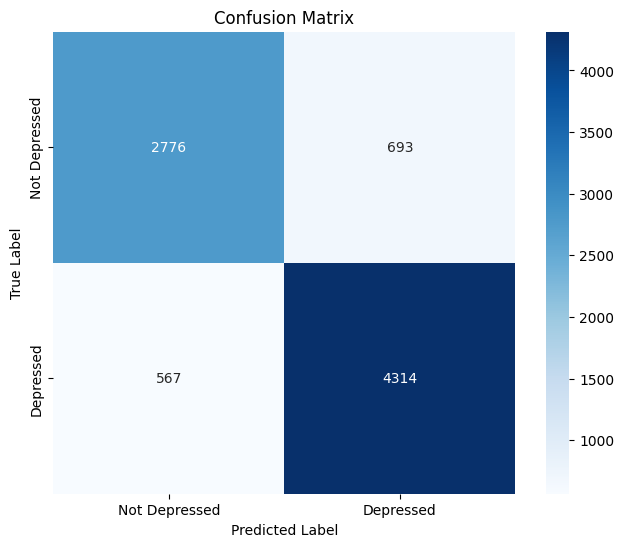

In [ ]:
from sklearn.metrics import confusion_matrix
# Calculate confusion matrix: confusion_matrix()
# (1 marks)
confu_mat = confusion_matrix(y_test, y_test_pred)


# Print confusion matrix using a heatmap: sns.heatmap()
plt.figure(figsize=(8, 6))
sns.heatmap(confu_mat,
           xticklabels=['Not Depressed', 'Depressed'],
           yticklabels=['Not Depressed', 'Depressed'],
           square=True,
           annot=True,
           cbar=True,
           fmt='d',
           cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
# Print classification report: classification_report()
# (1 marks)
print(classification_report(y_test, y_test_pred))


              precision    recall  f1-score   support

           0       0.83      0.80      0.82      3469
           1       0.86      0.88      0.87      4881

    accuracy                           0.85      8350
   macro avg       0.85      0.84      0.84      8350
weighted avg       0.85      0.85      0.85      8350



### Additional Models Comparison (2 marks)

Let's compare the Logistic Regression with Naive Bayes and K-Nearest Neighbors models on the same dataset.

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

# Compare Logistic Regression, Naive Bayes, and KNN models
# Initialize models (0.5 marks)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier()

}

# Split the full dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Train and evaluate each model using the full dataset (0.5 marks)
model_results = {}
conf_matrices = {}

for name, model_instance in models.items():
    # Train the model
    model_instance.fit(X_train,y_train)

    # Make predictions
    y_pred = model_instance.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred) # Use y_test for accuracy calculation

    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Store the results
    model_results[name] = accuracy
    conf_matrices[name] = cm

    # Print results (moved outside loop for cleaner output)
# print("Model Comparison:")
# for name, accuracy in model_results.items():
#     print(f"{name}: Accuracy = {accuracy:.4f}")

print("Model Comparison:")
for name, accuracy in model_results.items():
    print(f"{name}: Accuracy = {accuracy:.4f}")

Model Comparison:
Logistic Regression: Accuracy = 0.8531
Naive Bayes: Accuracy = 0.8383
K-Nearest Neighbors: Accuracy = 0.7541


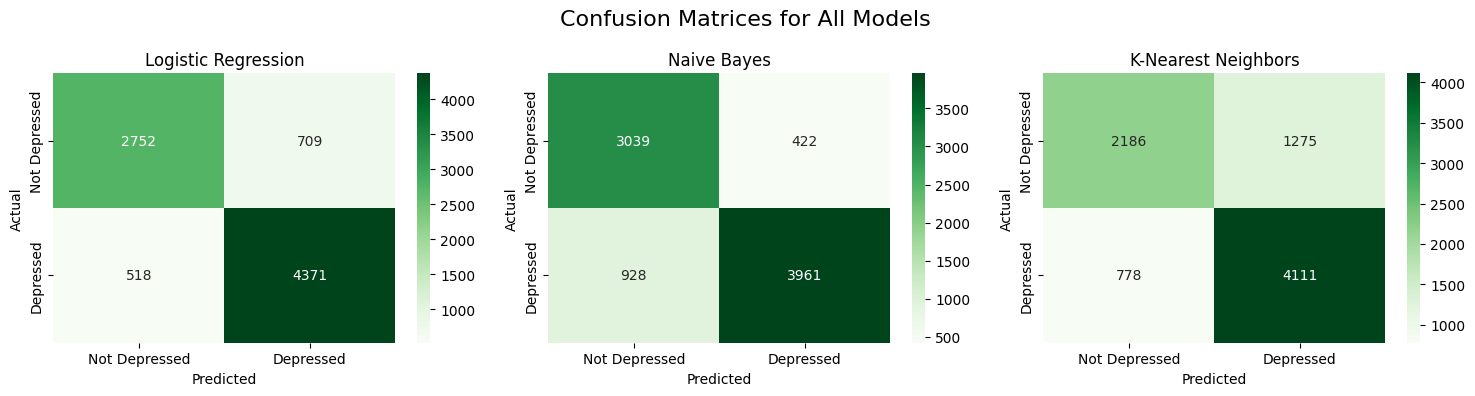

In [ ]:
# Visualize confusion matrices for all models (You can use heatmap again)
# (1 marks)
# Print confusion matrix using a heatmap: sns.heatmap()
plt.figure(figsize=(15, 4))
class_labels = ["Not Depressed", "Depressed"]

for i, (name, cm) in enumerate(conf_matrices.items(), 1):
    plt.subplot(1, 3, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f"{name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.suptitle("Confusion Matrices for All Models", fontsize=16)
plt.tight_layout()
plt.show()

### Questions and Analysis (7 marks)

1. Is the dataset balanced? Does it affect model performance? (1 mark)
2. Does the model overfit or underfit for each of the 3 cases? (1 marks)  
3. How do the training and testing accuracy change depending on the amount of data used? Explain with values. (1 mark)
4. In this case, what do a false positive and a false negative represent? Which one is worse? (1 marks)
5. Based on your answer to question 4, would you want to maximize precision or recall? How would you do this? (1 marks)
6. Based on the Log Loss for each of the 3 cases, what can you say about the model in each instance? What is potentially causing these differences? (1 marks)
7. Compare the performance of Logistic Regression, Naive Bayes, and K-Nearest Neighbors models. Which performs best and why? Explain based on each algorithm's characteristics and assumptions. (1 marks)

### Answer here (double click)
1:
The dataset isn’t balanced. In the class histogram, there are noticeably more depressed students than not depressed. Specifically, there are 3649 “Not Depressed” students and 4881 “Depressed” students.
This imbalance may affect model performance as the model may learn to favour the class of depressed students, meaning that the model could become biased towards predicting depressed slightly more often.

2:
For the full dataset (all features), the training accuracy was 0.846, and the test accuracy was 0.849. As the training and testing are almost identical, the model is not overfitting nor underfitting.
When using only the first two features, the training accuracy is 0.631 and the test accuracy is 0.637. As these accuracies are both low, the model is underfitting.
In the small dataset, the training accuracy was 0.863 and the testing accuracy was 0.841. While it is small, there was a slight drop in accuracy on the training set. This implies that there is a slight overfitting occurring.

3:
As mentioned in the last question, for the full dataset (all features), the training accuracy was 0.846, and the test accuracy was 0.849. With this larger dataset size, the training and testing accuracy are both high and consistent with each other.
When using only the first two features, the training accuracy is 0.631 and the test accuracy is 0.637.  As there are only two features, the model has far less information to work with, so the accuracy in both cases drops.
In the small dataset, the training accuracy was 0.863 and the testing accuracy was 0.841. While it is small, there was a slight drop in accuracy on the training set, which is likely partially due to the smaller size of this dataset.


4:
In this case, a false positive is when a patient is predicted to be depressed, but in reality is not depressed. A false negative is when a patient is predicted to be not depressed, but in reality is depressed.
Which is worse is subjective. In my opinion, a false negative is worse. Predicting that someone who is struggling with depression isn’t depressed could prevent them from getting the support they need, which has great implications for safety.
Conversely, a false positive is inconvenient, or perhaps confusing for the patient, as they would be provided with a diagnosis and resources that they may not need. Additionally, a false positive may be bad because it reflects the dataset imbalance, but this does not have as drastic of real-world consequences as the false negative.

5:
As false negatives are worse, we want to maximize recall. The formula for recall is the true positives (TP) divided by TP plus false negatives, with the denominator representing all actually depressed students. In this case, we want to minimize the number of times the model predicts a depressed student as not depressed (a false negative). Minimizing the false negatives decreases the denominator, and increases the recall.

6:
When the log loss is low, the model is the most confident and accurate. This occurs in the case of the full dataset, where the log loss was 0.352. When the model operates using the small dataset, it is slightly less confident and accurate, with a log loss of 0.385. A high log loss indicates that the predictions are poor and the model isn’t confident. The highest log loss occurred in the case of the first two columns, with a log loss of 0.652.

7:
The logistic regression accuracy was 0.8531. The Naive Bayes accuracy was 0.8383. The KNN model accuracy was 0.7541.
Logistic regression was the best because it thrives on datasets that are large and relatively linear. Compared to Naive Bayes, logistic regression handles multicollinearity better. Additionally, because it’s trained using maximum likelihood, its decision boundaries end up being more stable and reliable.
Naive Bayes assumes features are independent, but the features in this dataset aren’t. However, Naive Bayes still outperforms the KNN model because Naive Bayes works well with large datasets.
The KNN model doesn’t perform as well with high dimensional data like the one in this dataset, where we have sixteen features. KNN also doesn’t work as well with large datasets.











---
---

# **PART 3: MNIST Handwritten Digit Classification using MLP & CNN (30 Marks)**

This part compares two neural network architectures for handwritten digit classification:
- **Multi-Layer Perceptron (MLP)**: A traditional fully-connected neural network
- **Convolutional Neural Network (CNN)**: A specialized architecture for image processing


The MNIST database of handwritten digits has a training set of 60,000 examples, and a test set of 10,000 examples. This dataset we're using uses the work of Joseph Redmon to provide the MNIST dataset in a CSV format. And it can be downloaded from https://www.kaggle.com/datasets/hojjatk/mnist-dataset

The dataset consists of two files:
- mnist_train.csv
- mnist_test.csv

The mnist_train.csv file contains the 60,000 training examples and labels. The mnist_test.csv contains 10,000 test examples and labels. Each row consists of 785 values: the first value is the label (a number from 0 to 9) and the remaining 784 values are the pixel values (a number from 0 to 255).

Acknowledgements:
- Yann LeCun, Courant Institute, NYU
- Corinna Cortes, Google Labs, New York
- Christopher J.C. Burges, Microsoft Research, Redmond

![MNIST dataset](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png)

We'll train both models on the MNIST dataset and compare their performance.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Step 1: Library Imports

Import the necessary libraries for data processing, model building, and evaluation.

In [ ]:
# Library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

### Step 2: Dataset Loading (2 marks)

Load the MNIST dataset from CSV files. The MNIST dataset contains 70,000 images of handwritten digits (0-9).

Then visualize some sample images.

In [ ]:
# Load MNIST dataset from CSV files
train_csv_path = "/content/drive/MyDrive/ENGG680_2025_Fall/Lab_Assignment2/part3-data/mnist_train.csv"
test_csv_path = "/content/drive/MyDrive/ENGG680_2025_Fall/Lab_Assignment2/part3-data/mnist_test.csv"

# Load training data
# The first line is the label, the rest are pixel values
# (0.5 marks)
train_data = pd.read_csv(train_csv_path)
y_train = train_data.iloc[:, 0]
X_train = train_data.iloc[:, 1:]

# CSV stores each image as a single row of 784 pixels, but we need 28x28 matrix for image processing
# Reshape from flat array (784,) to 2D image format (28, 28)
# (0.5 marks)
X_train = X_train.values.reshape(X_train.shape[0], 28, 28)

# Load test data (0.5 marks)
test_data = pd.read_csv(test_csv_path)
y_test = test_data.iloc[:, 0]
X_test = test_data.iloc[:, 1:]

# Reshape test data to match training data format (0.5 marks)
X_test = X_test.values.reshape(X_test.shape[0], 28, 28)


# Display the shapes of training and test sets
print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)


Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


Let's visualize some sample images to understand what our models will be learning from.

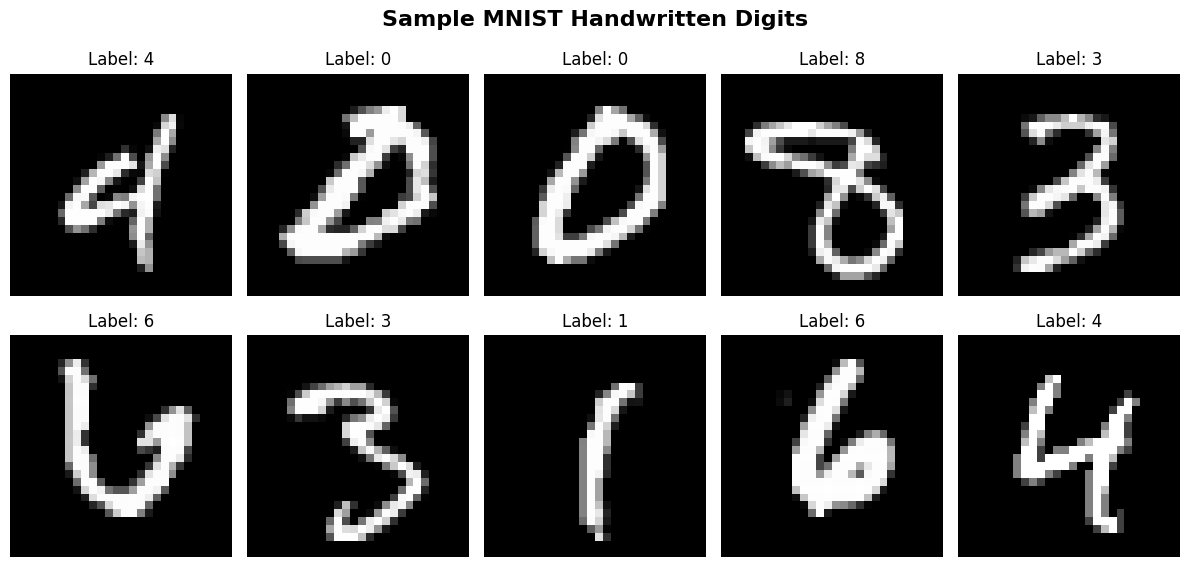

In [ ]:
# Visualize sample images from the dataset as a grid of 10 images (2 rows x 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample MNIST Handwritten Digits', fontsize=16, fontweight='bold')

# Display 10 random samples
# Use a loop
for i in range(10):
    row = i // 5
    col = i % 5

    # Get a random sample
    idx = np.random.randint(0, len(X_train))
    image = X_train[idx]
    label = y_train[idx]

    # Display the image
    axes[row, col].imshow(image, cmap='gray')
    axes[row, col].set_title(f'Label: {label}', fontsize=12)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Step 3: Data Preprocessing (1 mark)

Normalize pixel values to [0,1] range and convert labels to one-hot encoding for multi-class classification.

Why normalize? Neural networks work better with smaller input values (0-1 vs 0-255)
- Faster convergence during training
- Prevents gradient explosion/vanishing
- Makes learning more stable

Why one-hot? Transform labels from integers (0,1,2...9) to binary vectors

- Example: label "3" becomes [0,0,0,1,0,0,0,0,0,0]

- This allows softmax output layer to predict probabilities for each class

In [ ]:
# Normalize pixel values from [0, 255] to [0, 1] range
# hint: divide by 255.0 (0.5 marks)

X_train_normalized = X_train / 255.0
X_test_normalized = X_test / 255.0

# Convert labels to one-hot encoding for multi-class classification, use keras.utils.to_categorical to do it
# (0.5 marks)
num_classes = 10
y_train_categorical = keras.utils.to_categorical(y_train, num_classes)
y_test_categorical = keras.utils.to_categorical(y_test, num_classes)


### Step 4: MLP Model Creation and Training (7 marks)

Create a Multi-Layer Perceptron model with fully connected layers. This model treats each pixel as an independent feature.

This created model can be used for fit, predict and evaluate the dataset through calling mlp_model.fit(), mlp_model.predict() and mlp_model.evaluate(), you can consider it as a inbuild model right now.

Hint: We will use tf.keras.layers function, and add flatten layer, hidden layer, dropout layer, hidden layer, dropout layer and output layer.

In [ ]:
# Create MLP model, add each of layers with their parameters

def create_mlp_model():
    model = tf.keras.Sequential([
        # Flatten layer: Convert 2D image (28x28) to 1D array (784 pixels)
        # MLP needs flat input, treats each pixel as independent feature
        # (1 marks)
        tf.keras.layers.Flatten(input_shape=(28,28)),


        # First hidden layer: 128 neurons with ReLU activation
        # ReLU = max(0, x), helps with vanishing gradient problem
        # (1 marks)
        tf.keras.layers.Dense(128, activation='relu'),


        # Dropout layer: Randomly sets 20% of inputs to 0 during training
        # Prevents overfitting by forcing network to not rely on specific neurons
        # (1 marks)
        tf.keras.layers.Dropout(0.2),

        # Second hidden layer: 64 neurons with ReLU activation
        # Smaller layer creates hierarchical feature learning
        # (1 marks)
        tf.keras.layers.Dense(64, activation='relu'),

        # Another dropout layer for regularization, same with above
        # (1 marks)
        tf.keras.layers.Dropout(0.2),

        # Output layer: 10 neurons (one for each digit 0-9) with softmax activation
        # Softmax converts outputs to probabilities that sum to 1
        # (1 marks)
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    # Compile model with optimizer, loss function, and metrics
    # Adam: adaptive learning rate optimizer
    # Categorical crossentropy: loss for multi-class classification
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Creating the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
mlp_model = create_mlp_model()
print("MLP Model created")

MLP Model created


**Use .fit() to train MLP model**

In [ ]:
# EPOCHS: Number of complete passes through entire training dataset, use 5 epochs
# (0.5 marks)
EPOCHS = 5

# BATCH_SIZE: Number of samples processed before updating model weights
# Larger batch = more stable gradients but more memory usage
# Use 128 as batch size
# (0.5 marks)
BATCH_SIZE = 128

# Train MLP model using mlp_model we compile.
# Use 10% of training data for validation, validation_split=0.1
# Silent training (no progress output), verbose=0
mlp_history = mlp_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)


print("MLP training completed")

MLP training completed


### Step 5: CNN Model Creation and Training (7 marks)

Create a Convolutional Neural Network with convolutional and pooling layers. This model preserves spatial relationships between pixels.

#### Fundamental Difference between MLP and CCN:

**Key Architectural Differences:**
- **MLP**: Input → Flatten → Dense layers → Output (treats pixels independently)
- **CNN**: Input → Reshape → Conv+Pool layers → Flatten → Dense layers → Output (learns spatial patterns first)

**The CNN Advantage:**
1. **Convolutional Layers**: Extract spatial features (edges, curves, shapes) that MLP cannot detect
2. **Pooling Layers**: Provide translation invariance and reduce computational load
3. **Feature Hierarchy**: Early layers detect simple patterns, deeper layers combine them into complex features
4. **Parameter Sharing**: Same filter applied across entire image, making CNN more efficient

**Why CNNs End with Dense Layers:**
- Convolutional layers act as **feature extractors** (learn "what" is in the image)
- Dense layers act as **classifiers** (decide "which digit" based on extracted features)
- This is a common pattern: **Feature Extraction (CNN) + Classification (MLP)**

**The Real Difference:**
- **MLP Dense layers**: Work with raw pixel values (784 individual numbers)
- **CNN Dense layers**: Work with high-level spatial features learned by convolutional layers

Hint: We will use tf.keras.layers function again, reshape it firstly, then add Conv2D, MaxPooling2D, Conv2D, MaxPooling2D, Conv2D, and do same last two steps like MLP.

In [ ]:
# Similar process with creating MLP model
# Create CNN model - Different from MLP in how it processes spatial information
def create_cnn_model():
    model = tf.keras.Sequential([
        # Reshape: Add channel dimension (28, 28, 1) for grayscale images (0.5 marks)
        tf.keras.layers.Reshape((28, 28, 1)),

        # Conv2D: Applies 32 filters of size 3x3 to detect local patterns (edges, curves) (1 marks)
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),

        # Reduces image size by taking maximum value in 2x2 regions (0.5 marks)
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Conv2D: Second convolutional layer, 64 filters learn more complex patterns (1 marks)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),

        # MaxPooling2D: Another pooling layer to further reduce spatial dimensions (0.5 marks)
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Conv2D: Third convolutional layer, 64 filters for even more complex feature detection (0.5 marks)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),

        # Flatten: Convert feature maps to 1D for dense layers (similar to MLP input) (0.5 marks)
        tf.keras.layers.Flatten(),

        # Dense layers: Same as MLP, but now working with CNN-extracted features (0.5 marks)
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    # Same compile step with MLP (1 marks)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Create the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
cnn_model = create_cnn_model()
print("CNN Model created")

CNN Model created


**Use .fit() to train CNN model**

In [ ]:
# Train CNN model using cnn_model we compile, same parameters as MLP
# (1 marks)
cnn_history = cnn_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)

print("CNN training completed")

CNN training completed


### Step 6: Model Evaluation and Comparison (4 marks)

Evaluate both models on the test set and compare their performance with visualizations.

Using .predict(), .evaluate() functions as we used in part2

In [ ]:
# Evaluate both models on test set
# Get test loss and accuracy, make predictions, convert probabilities to class labels

# your code here for mlp (1.5 marks)
mlp_loss, mlp_accuracy = mlp_model.evaluate(X_test_normalized, y_test_categorical)
mlp_predictions = mlp_model.predict(X_test_normalized)



# Note: The model outputs class probabilities (softmax). We convert these to discrete class labels by taking the index of the maximum probability (argmax).
# These integer labels (0-9) are required for computing accuracy, building confusion matrices, and for plotting / comparing predicted vs true labels.
mlp_predicted_classes = np.argmax(mlp_predictions, axis=1)

# your code here for cnn (1.5 marks)
cnn_loss, cnn_accuracy = cnn_model.evaluate(X_test_normalized, y_test_categorical)
cnn_predictions = cnn_model.predict(X_test_normalized)

# Similarly, convert CNN predicted probabilities to class labels
cnn_predicted_classes = np.argmax(cnn_predictions, axis=1)

# Display Results
print("MLP Test Loss:", mlp_loss)
print("MLP Test Accuracy:", mlp_accuracy)
print("CNN Test Loss:", cnn_loss)
print("CNN Test Accuracy:", cnn_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9695 - loss: 0.0985
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9881 - loss: 0.0357
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
MLP Test Loss: 0.08734899759292603
MLP Test Accuracy: 0.972599983215332
CNN Test Loss: 0.03055521287024021
CNN Test Accuracy: 0.9898999929428101


Performance comparison visualization

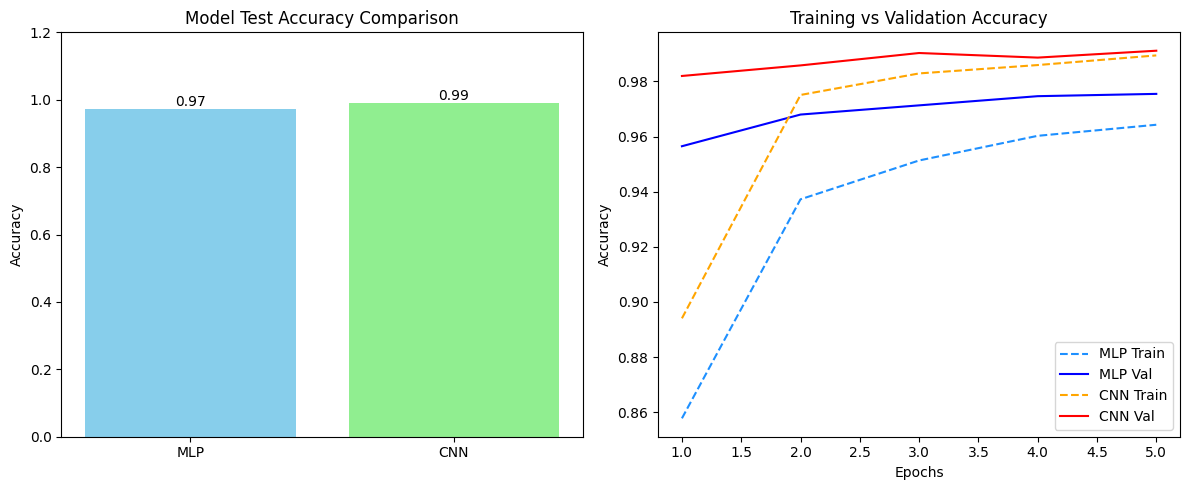

In [ ]:
# Create side-by-side bar chart for model accuracy comparison and line plot for training progress comparison
# (1 marks)
# put them in a single figure horizontally
fig, axes = plt.subplots(1,2, figsize=(12,5))
models = ['MLP','CNN']
accuracies = [mlp_accuracy, cnn_accuracy]

# Add titles, labels, legends for clarity
axes[0].bar(models, accuracies, color=['skyblue', 'lightgreen'])
axes[0].set_title('Model Test Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0,1.2)
for i, acc in enumerate(accuracies):
  axes[0].text(i, acc + 0.01, f"{acc:.2f}", ha='center', fontsize=10)

# hint: use .history() function to get training history from the training step

epochs = range(1, len(mlp_history.history['accuracy'])+1)

axes[1].plot(epochs, mlp_history.history['accuracy'], label='MLP Train', linestyle='--', color='dodgerblue')
axes[1].plot(epochs, mlp_history.history['val_accuracy'], label='MLP Val', color='blue')

axes[1].plot(epochs, cnn_history.history['accuracy'], label='CNN Train', linestyle='--', color='orange')
axes[1].plot(epochs, cnn_history.history['val_accuracy'], label='CNN Val', color='red')

axes[1].set_title('Training vs Validation Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

### Step 7: Prediction Analysis Visualization (4 marks)

Let's examine some specific predictions to see how each model performs on individual samples.

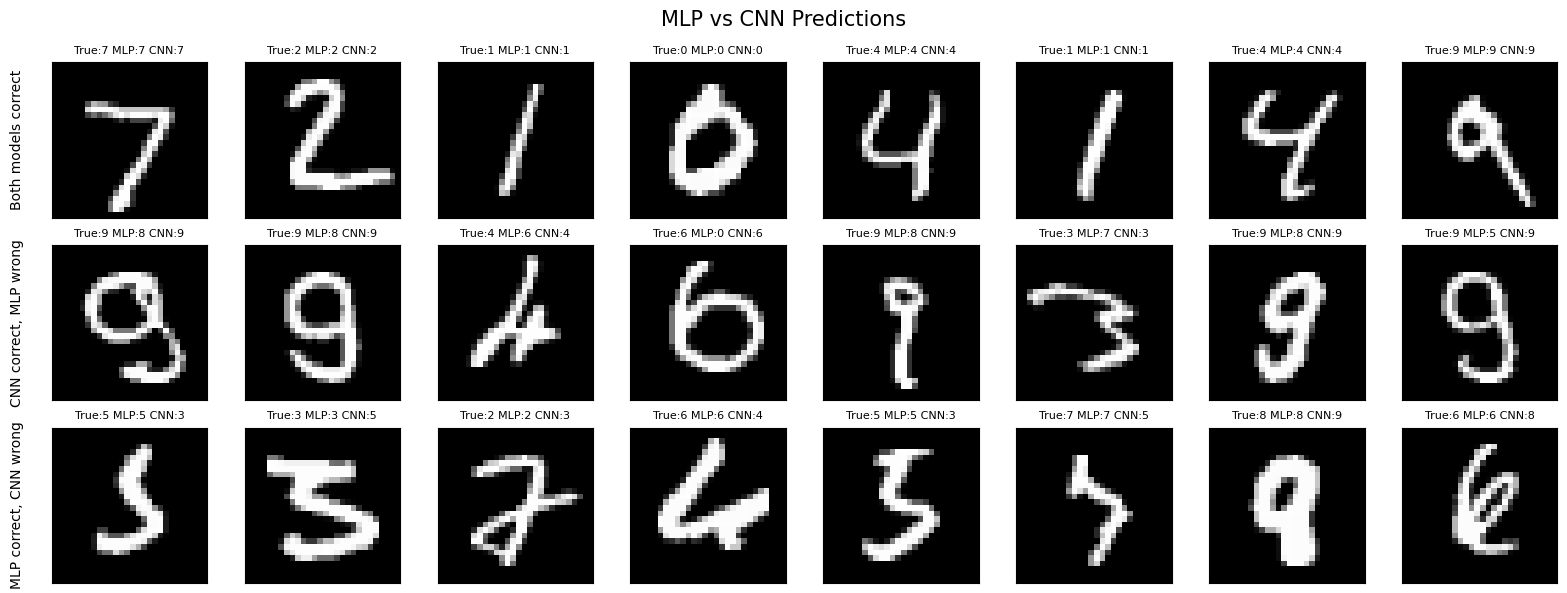

In [ ]:
# Visualize correct and incorrect predictions, create a 3x8 grid
# First row: Both models correct
# Second row: CNN correct, MLP wrong
# Third row: MLP correct, CNN wrong

# Create subplots
# your code here (1 marks)
fig, axes = plt.subplots(3, 8, figsize=(16, 6))
fig.suptitle("MLP vs CNN Predictions", fontsize=15)

# Find correct predictions for each case
# Sample for both_correct
both_correct = (mlp_predicted_classes == y_test) & (cnn_predicted_classes == y_test)
both_correct_indices = np.where(both_correct)[0][:8]

# your code here (1 marks)
cnn_correct_mlp_wrong = (cnn_predicted_classes == y_test) & (mlp_predicted_classes != y_test)
cnn_correct_mlp_wrong_indices = np.where(cnn_correct_mlp_wrong)[0][:8]

mlp_correct_cnn_wrong = (mlp_predicted_classes == y_test) & (cnn_predicted_classes != y_test)
mlp_correct_cnn_wrong_indices = np.where(mlp_correct_cnn_wrong)[0][:8]

# Plot examples, you can learn how to plot them from previous plotting code in Part 2
# Add a title for each graph showing the true label and both model predictions
# hint: use for loop to iterate through the indices and plot each image
# your code here (2 marks)
for i, idx in enumerate(both_correct_indices):
    ax = axes[0, i]
    ax.get_xaxis().set_visible(False)
    if i != 0:
        ax.yaxis.set_visible(False)
    ax.tick_params(axis='y', left=False, labelleft=False)
    ax.imshow(X_test[idx], cmap='gray')
    ax.set_title(f"True:{y_test[idx]} MLP:{mlp_predicted_classes[idx]} CNN:{cnn_predicted_classes[idx]}", fontsize=8)
axes[0, 0].set_ylabel("Both models correct", fontsize=10, labelpad=20)

for i, idx in enumerate(cnn_correct_mlp_wrong_indices):
    ax = axes[1, i]
    ax.get_xaxis().set_visible(False)
    if i != 0:
        ax.yaxis.set_visible(False)
    ax.tick_params(axis='y', left=False, labelleft=False)
    ax.imshow(X_test[idx], cmap='gray')
    ax.set_title(f"True:{y_test[idx]} MLP:{mlp_predicted_classes[idx]} CNN:{cnn_predicted_classes[idx]}", fontsize=8)
axes[1, 0].set_ylabel("CNN correct, MLP wrong", fontsize=10, labelpad=20)

for i, idx in enumerate(mlp_correct_cnn_wrong_indices):
    ax = axes[2, i]
    ax.get_xaxis().set_visible(False)
    if i != 0:
        ax.yaxis.set_visible(False)
    ax.tick_params(axis='y', left=False, labelleft=False)
    ax.imshow(X_test[idx], cmap='gray')
    ax.set_title(f"True:{y_test[idx]} MLP:{mlp_predicted_classes[idx]} CNN:{cnn_predicted_classes[idx]}", fontsize=8)
axes[2, 0].set_ylabel("MLP correct, CNN wrong", fontsize=10, labelpad=20)

plt.tight_layout()
plt.show()

## Questions and Analysis (5 marks)

1. Which model performed better and why? (1 marks)
2. How do the training curves compare between the two models? (1 marks)
3. What does the accuracy improvement percentage tell us? (1 marks)
4. Why didn't we need many epochs for good results? (1 marks)
5. What would happen with more complex images? (1 marks)

1. The CNN model performed better because the test accuracy is 0.989 where as the MLP test accuracy is 0.9725. This is expected because CNNs are used to capture spatial patterns in images whereas MLPs flatten the image and lose spatial information.

2. The CNN curves are smoother and are consitently about the MLP curves indicating more stable learning. The CNN training and validation accuracy start higher and improve more quickly whereas the MLP improves more slowly and shows larger gap between training and validation early on.

3. The accuracy improvement perentage tells us which model performed better on the same task. The imporvement from MLPs 97% to CNNS 99% shows that CNN is better for classifying challenging digits.

4. We didn't need many epochs for good results because the problem is quite simple and didn't have complex patterns to learn. With only a few epochs both models reach near optimal performance where additional training would bring minimal gain.

5. If we moved to more complex images, the difference between MLP and CNN model accuracy would be drastically more different then it is with these images. This is because MLPs flatten which ruins vision tasks and CNN filters can visualize shape. Although the CNN would still handle the problem better, it would need more epochs, deeper layers, and more data to have optimal performance.
